# MNIST — Comparison of Optimizers

This notebook trains the same neural-network architecture using different optimizers and compares their convergence.

### Optimizers compared
- Adam
- AdamW
- RMSprop
- Adadelta
- Adagrad
- SGD

For each optimizer, the following are recorded:
- Training loss per epoch
- Test accuracy per epoch
- Final test accuracy
- Final training loss
- Training time

In [2]:
import os
import time
import copy
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.11.0+cu128
Device: cuda


## 1. Configuration

In [3]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset paths
TRAIN_PATH = r"D:\Deep_Learning_Class\Reduced MNIST Data\Reduced Training data"
TEST_PATH  = r"D:\Deep_Learning_Class\Reduced MNIST Data\Reduced Testing data"

# Training configuration
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

print("Device:", device)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LR)

Device: cuda
Batch size: 64
Epochs: 10
Learning rate: 0.001


## 2. Model Implementation

In [4]:
class NeuralNetwork:
    def __init__(self, device, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.model = None
        self.device = device

    def build_model(self):
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 392),
            nn.ReLU(),

            nn.Linear(392, 392),
            nn.ReLU(),

            nn.Linear(392, 10)
        ).to(self.device)

        return self

    def _get_optimizer(self, optimizer_name):
        if optimizer_name == "Adam":
            optimiser = torch.optim.Adam(
                self.model.parameters(), lr=self.lr
            )
        elif optimizer_name == "AdamW":
            optimiser = torch.optim.AdamW(
                self.model.parameters(), lr=self.lr
            )
        elif optimizer_name == "RMSprop":
            optimiser = torch.optim.RMSprop(
                self.model.parameters(), lr=self.lr
            )
        elif optimizer_name == "Adadelta":
            optimiser = torch.optim.Adadelta(
                self.model.parameters(), lr=self.lr
            )
        elif optimizer_name == "Adagrad":
            optimiser = torch.optim.Adagrad(
                self.model.parameters(), lr=self.lr
            )
        elif optimizer_name == "SGD":
            optimiser = torch.optim.SGD(
                self.model.parameters(), lr=self.lr
            )
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_name}")

        return optimiser

    def fit(self, train_loader, test_loader=None, optimizer_name="Adam"):
        optimiser = self._get_optimizer(optimizer_name)
        criterion = nn.CrossEntropyLoss()

        history = {
            "train_loss": [],
            "test_accuracy": [],
            "epoch_time": []
        }

        for epoch in range(self.epochs):
            start_time = time.time()

            self.model.train()
            running_loss = 0.0
            total_samples = 0

            for input, target in train_loader:
                input = input.float().to(self.device)
                target = target.long().to(self.device)

                # Forward Pass
                y_hat = self.model(input)

                # Loss calculation
                loss = criterion(y_hat, target)

                # Clear the old gradients
                optimiser.zero_grad()

                # Back propagation
                loss.backward()

                # Weight updates
                optimiser.step()

                running_loss += loss.item() * input.size(0)
                total_samples += input.size(0)

            epoch_loss = running_loss / total_samples
            history["train_loss"].append(epoch_loss)

            # Evaluate after every epoch
            if test_loader is not None:
                accuracy = self.evaluate(test_loader)
                history["test_accuracy"].append(accuracy)
            epoch_time = time.time() - start_time
            history["epoch_time"].append(epoch_time)

            if test_loader is not None:
                print(
                    f"Epoch {epoch + 1:2d}/{self.epochs} | "
                    f"Loss: {epoch_loss:.4f} | "
                    f"Test Accuracy: {accuracy:.2f}% | "
                    f"Time: {epoch_time:.2f}s"
                )
            else:
                print(
                    f"Epoch {epoch + 1:2d}/{self.epochs} | "
                    f"Loss: {epoch_loss:.4f} | "
                    f"Time: {epoch_time:.2f}s"
                )

        return history

    def predict(self, X):
        self.model.eval()
        if not torch.is_tensor(X):
            X = torch.tensor(X, dtype=torch.float32)

        X = X.to(self.device)
        if X.ndim == 1:
            X = X.unsqueeze(0)

        with torch.no_grad():
            output = self.model(X)
        return torch.argmax(output, dim=1)

    def evaluate(self, test_loader):
        self.model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for input, target in test_loader:
                input = input.float().to(self.device)
                target = target.long().to(self.device)

                output = self.model(input)
                predictions = torch.argmax(output, dim=1)

                correct += (predictions == target).sum().item()
                total += target.size(0)

        return 100.0 * correct / total

## 3. Dataset Loading with OpenCV
Each image is read using OpenCV as a grayscale image, normalized to `[0, 1]`, and flattened from `28 × 28` to `784` features.

In [5]:
class MNISTLoader(Dataset):
    def __init__(self, path):
        self.path = path
        self.data = []
        self.labels = []

        for digit in sorted(os.listdir(self.path)):
            digit_path = os.path.join(self.path, digit)

            if not os.path.isdir(digit_path):
                continue

            for file in sorted(os.listdir(digit_path)):
                img_path = os.path.join(digit_path, file)

                x = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if x is None:
                    continue

                x = x.astype("float32") / 255.0
                x = x.reshape(-1)

                self.data.append(x)
                self.labels.append(int(digit))

        self.data = np.array(self.data, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [6]:
train_set = MNISTLoader(TRAIN_PATH)
test_set = MNISTLoader(TEST_PATH)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training samples:", len(train_set))
print("Testing samples :", len(test_set))

X_batch, y_batch = next(iter(train_loader))

print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)

Training samples: 10000
Testing samples : 2000
Batch X shape: torch.Size([64, 784])
Batch y shape: torch.Size([64])


## 4. Inspecting a Few MNIST Images

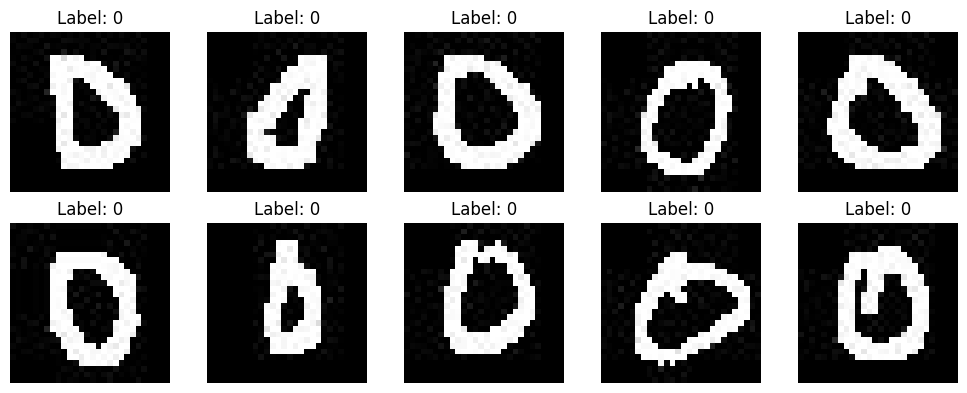

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, (image, label) in zip(axes.ravel(), [train_set[i] for i in range(10)]):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Optimizer Comparison

A fresh copy of the **same initial model weights** is used for every optimizer.

This is important: if every optimizer starts from a different random initialization, some of the observed difference could come from initialization rather than the optimizer itself.

In [9]:
optimizers = [
    "Adam",
    "AdamW",
    "RMSprop",
    "Adadelta",
    "Adagrad",
    "SGD"
]

# Build one reference model and save its initial weights.
reference_model = NeuralNetwork(
    device=device,
    lr=LR,
    epochs=EPOCHS
).build_model()

initial_weights = copy.deepcopy(reference_model.model.state_dict())

results = {}
models = {}

for optimizer_name in optimizers:
    print("\n" + "=" * 70)
    print(f"Training with {optimizer_name}")
    print("=" * 70)

    # Create a fresh model with the same architecture.
    model = NeuralNetwork(
        device=device,
        lr=LR,
        epochs=EPOCHS
    ).build_model()

    # Start every optimizer from exactly the same weights.
    model.model.load_state_dict(copy.deepcopy(initial_weights))

    history = model.fit(
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer_name=optimizer_name
    )

    results[optimizer_name] = history
    models[optimizer_name] = model


Training with Adam
Epoch  1/10 | Loss: 0.5322 | Test Accuracy: 90.05% | Time: 0.50s
Epoch  2/10 | Loss: 0.2144 | Test Accuracy: 93.55% | Time: 0.42s
Epoch  3/10 | Loss: 0.1388 | Test Accuracy: 94.30% | Time: 0.41s
Epoch  4/10 | Loss: 0.0971 | Test Accuracy: 93.90% | Time: 0.37s
Epoch  5/10 | Loss: 0.0717 | Test Accuracy: 96.30% | Time: 0.35s
Epoch  6/10 | Loss: 0.0527 | Test Accuracy: 95.95% | Time: 0.31s
Epoch  7/10 | Loss: 0.0352 | Test Accuracy: 96.05% | Time: 0.33s
Epoch  8/10 | Loss: 0.0218 | Test Accuracy: 96.55% | Time: 0.32s
Epoch  9/10 | Loss: 0.0171 | Test Accuracy: 95.05% | Time: 0.36s
Epoch 10/10 | Loss: 0.0107 | Test Accuracy: 96.60% | Time: 0.36s

Training with AdamW
Epoch  1/10 | Loss: 0.5263 | Test Accuracy: 91.10% | Time: 0.35s
Epoch  2/10 | Loss: 0.2187 | Test Accuracy: 93.30% | Time: 0.41s
Epoch  3/10 | Loss: 0.1446 | Test Accuracy: 94.15% | Time: 0.36s
Epoch  4/10 | Loss: 0.1033 | Test Accuracy: 95.55% | Time: 0.31s
Epoch  5/10 | Loss: 0.0778 | Test Accuracy: 95.60

## 6. Convergence: Training Loss

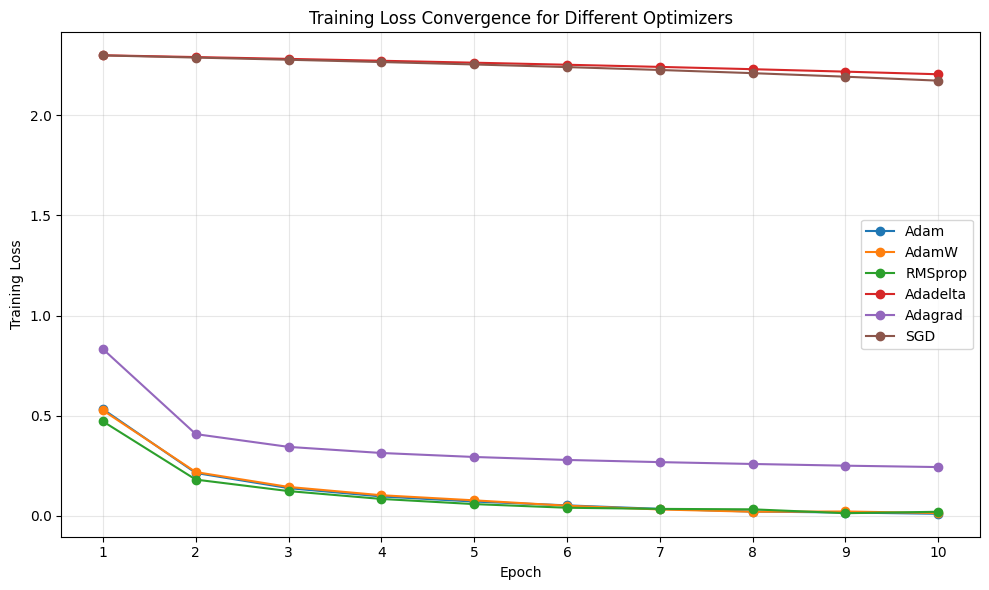

In [10]:
plt.figure(figsize=(10, 6))

epochs = range(1, EPOCHS + 1)

for optimizer_name in optimizers:
    plt.plot(
        epochs,
        results[optimizer_name]["train_loss"],
        marker="o",
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Convergence for Different Optimizers")
plt.xticks(list(epochs))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Convergence: Test Accuracy

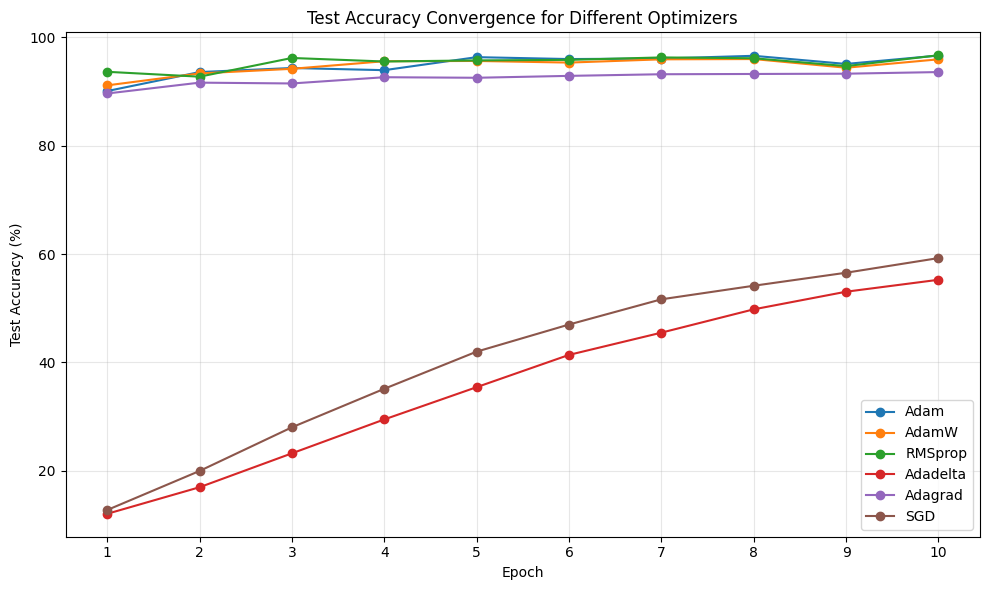

In [11]:
plt.figure(figsize=(10, 6))

for optimizer_name in optimizers:
    plt.plot(
        epochs,
        results[optimizer_name]["test_accuracy"],
        marker="o",
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Convergence for Different Optimizers")
plt.xticks(list(epochs))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Final Performance Comparison

In [12]:
final_accuracy = {
    name: results[name]["test_accuracy"][-1]
    for name in optimizers
}

final_loss = {
    name: results[name]["train_loss"][-1]
    for name in optimizers
}

training_time = {
    name: sum(results[name]["epoch_time"])
    for name in optimizers
}

print("Final Test Accuracy:")
for name in sorted(final_accuracy, key=final_accuracy.get, reverse=True):
    print(f"{name:10s}: {final_accuracy[name]:.2f}%")

print("\nFinal Training Loss:")
for name in optimizers:
    print(f"{name:10s}: {final_loss[name]:.4f}")

print("\nTotal Training Time:")
for name in optimizers:
    print(f"{name:10s}: {training_time[name]:.2f} seconds")

Final Test Accuracy:
RMSprop   : 96.65%
Adam      : 96.60%
AdamW     : 95.90%
Adagrad   : 93.55%
SGD       : 59.25%
Adadelta  : 55.25%

Final Training Loss:
Adam      : 0.0107
AdamW     : 0.0145
RMSprop   : 0.0208
Adadelta  : 2.2038
Adagrad   : 0.2438
SGD       : 2.1719

Total Training Time:
Adam      : 3.72 seconds
AdamW     : 3.51 seconds
RMSprop   : 3.43 seconds
Adadelta  : 3.81 seconds
Adagrad   : 3.31 seconds
SGD       : 3.07 seconds


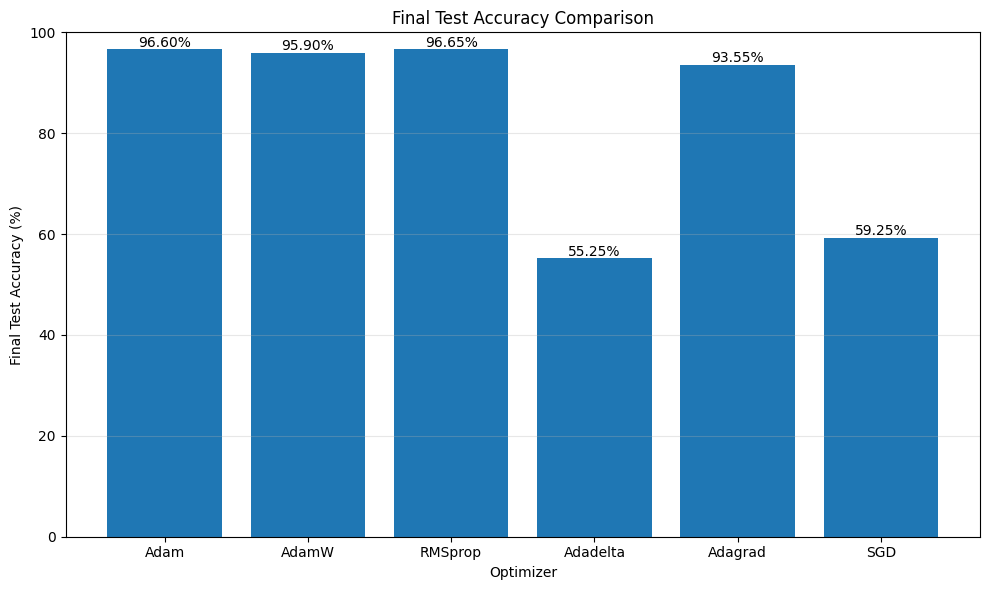

In [13]:
# Final test accuracy

plt.figure(figsize=(10, 6))

names = list(final_accuracy.keys())
values = list(final_accuracy.values())

bars = plt.bar(names, values)

plt.xlabel("Optimizer")
plt.ylabel("Final Test Accuracy (%)")
plt.title("Final Test Accuracy Comparison")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

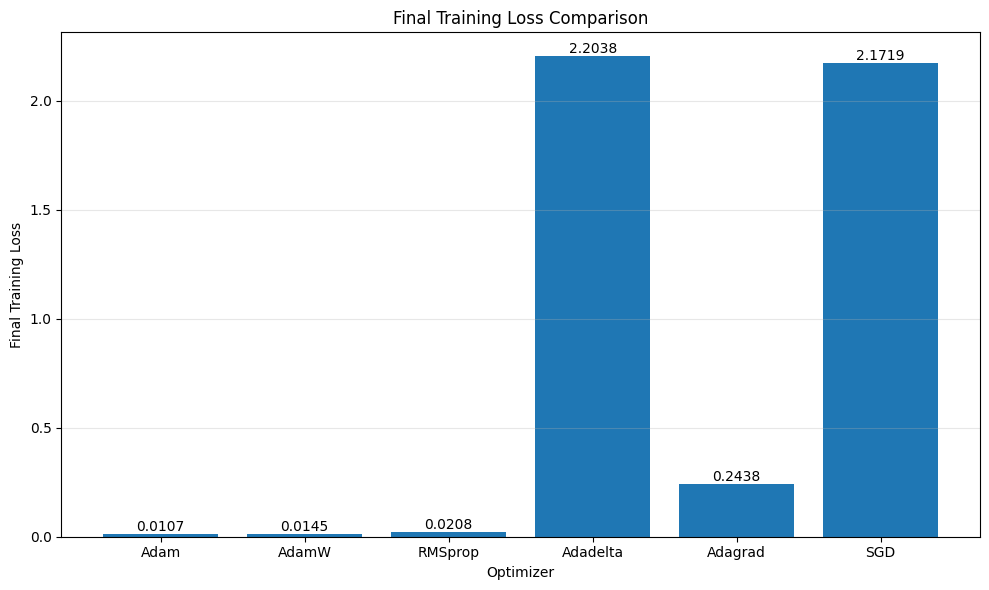

In [14]:
# Final training loss

plt.figure(figsize=(10, 6))

names = list(final_loss.keys())
values = list(final_loss.values())

bars = plt.bar(names, values)

plt.xlabel("Optimizer")
plt.ylabel("Final Training Loss")
plt.title("Final Training Loss Comparison")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 9. Making Predictions

Best optimizer : RMSprop
True label     : 0
Predicted label: 0


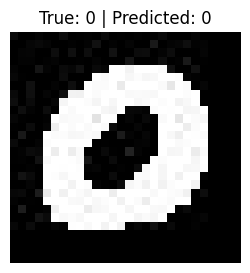

In [15]:
# Example prediction using the best-performing optimizer

best_optimizer = max(
    final_accuracy,
    key=final_accuracy.get
)

best_model = models[best_optimizer]

image, true_label = test_set[0]

prediction = best_model.predict(image).item()

print("Best optimizer :", best_optimizer)
print("True label     :", true_label)
print("Predicted label:", prediction)

plt.figure(figsize=(3, 3))
plt.imshow(image.reshape(28, 28), cmap="gray")
plt.title(f"True: {true_label} | Predicted: {prediction}")
plt.axis("off")
plt.show()